In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ml_dataset.tsv to ml_dataset.tsv


In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    roc_curve,
    recall_score
)

In [ ]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("ml_dataset.tsv", sep="\t", index_col=0)

print("Dataset shape:", df.shape)
print("Index name:", df.index.name)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)

Dataset shape: (439, 31)
Index name: Samples

Columns:
['SBS1', 'SBS5', 'SBS6', 'SBS7a', 'SBS7b', 'SBS10b', 'SBS15', 'SBS19', 'SBS31', 'SBS87', 'DBS1', 'DBS19', 'ID3', 'ID8', 'ID11', 'ID13', 'ID1', 'ID2', 'ID4', 'ID5', 'ID6', 'ID7', 'ID10', 'ID15', 'ID16', 'ID17', 'ID18', 'ID19', 'ID20', 'ID21', 'label']


,SBS1,SBS5,SBS6,SBS7a,SBS7b,SBS10b,SBS15,SBS19,SBS31,SBS87,...,ID7,ID10,ID15,ID16,ID17,ID18,ID19,ID20,ID21,label
Samples,,,,,,,,,,,,,,,,,,,,,
TCGA-3N-A9WB,7,4,0.0,96,61,29,0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
TCGA-3N-A9WC,74,111,0.0,1160,937,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
TCGA-3N-A9WD,39,19,0.0,591,444,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
TCGA-BF-A1PU,9,0,0.0,20,67,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
TCGA-BF-A1PV,17,3,0.0,172,140,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0



Class distribution:
label
1    361
0     78
Name: count, dtype: int64

Class distribution (%):
label
1    82.232346
0    17.767654
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 2. BASIC DATA CHECK
# ============================================================

print("Total NaNs in dataset:", df.isna().sum().sum())

print("\nColumn types:")
print(df.dtypes.value_counts())

# check if label exists
assert "label" in df.columns, "Column 'label' not found!"

# check labels
print("\nUnique labels:", sorted(df["label"].unique()))

Total NaNs in dataset: 0

Column types:
float64    24
int64       7
Name: count, dtype: int64

Unique labels: [np.int64(0), np.int64(1)]


In [ ]:
# ============================================================
# 3. DEFINE X AND y
# ============================================================

X = df.drop(columns=["label"])
y = df["label"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabel counts:")
print(y.value_counts())

print("\nNaNs in X:", X.isna().sum().sum())
print("NaNs in y:", y.isna().sum())

X shape: (439, 30)
y shape: (439,)

Label counts:
label
1    361
0     78
Name: count, dtype: int64

NaNs in X: 0
NaNs in y: 0


In [ ]:
# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label counts:")
print(y_train.value_counts())

print("\nTest label counts:")
print(y_test.value_counts())

Train shape: (351, 30)
Test shape: (88, 30)

Train label counts:
label
1    289
0     62
Name: count, dtype: int64

Test label counts:
label
1    72
0    16
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. LOGISTIC REGRESSION MODEL
# ============================================================

logreg_model = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

In [ ]:
# ============================================================
# 6. TRAIN LOGISTIC REGRESSION AND EVALUATE ON TEST SET
# ============================================================

logreg_model.fit(X_train, y_train)

# probability of class 1 = metastatic
proba = logreg_model.predict_proba(X_test)[:, 1]

# default threshold = 0.5
threshold = 0.5
pred = (proba >= threshold).astype(int)

roc_auc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
bal_acc = balanced_accuracy_score(y_test, pred)

print("=== Logistic Regression: test set performance ===")
print(f"Threshold: {threshold}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Balanced accuracy: {bal_acc:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    pred,
    target_names=["primary", "metastatic"]
))

=== Logistic Regression: test set performance ===
Threshold: 0.5
ROC-AUC: 0.807
PR-AUC: 0.954
Balanced accuracy: 0.764

Confusion matrix:
[[16  0]
 [34 38]]

Classification report:
              precision    recall  f1-score   support

     primary       0.32      1.00      0.48        16
  metastatic       1.00      0.53      0.69        72

    accuracy                           0.61        88
   macro avg       0.66      0.76      0.59        88
weighted avg       0.88      0.61      0.65        88



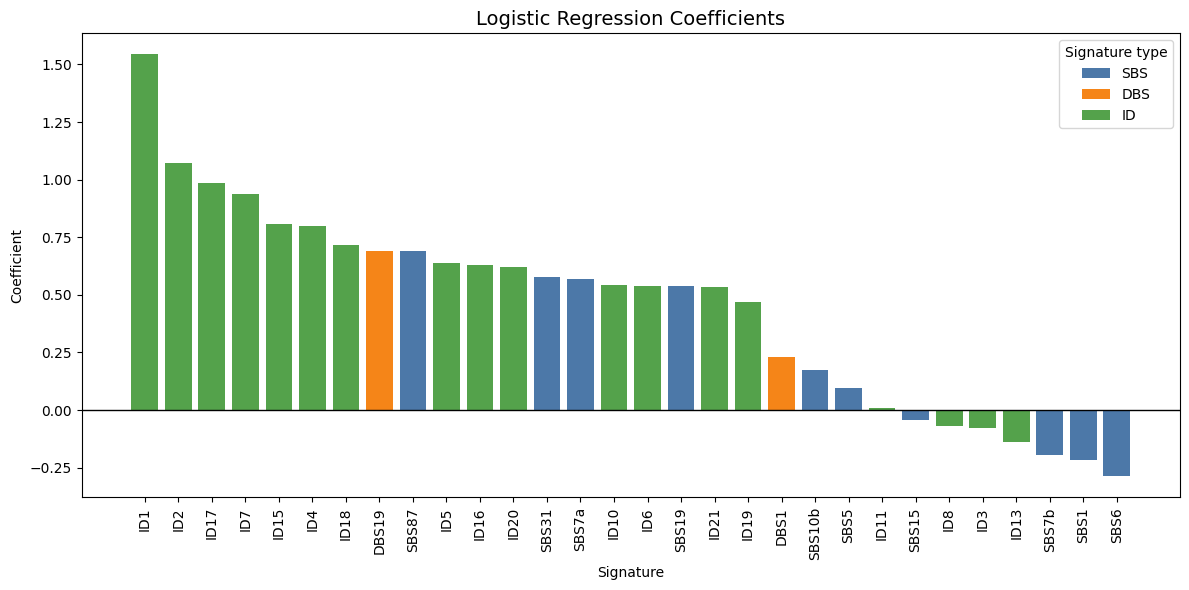

In [ ]:
# ============================================================
# 7. COEFFICIENT PLOT
# ============================================================

feature_names = X_train.columns
coef = logreg_model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "signature": feature_names,
    "coef": coef
})

def signature_type(signature):
    if signature.startswith("SBS"):
        return "SBS"
    elif signature.startswith("DBS"):
        return "DBS"
    elif signature.startswith("ID"):
        return "ID"
    else:
        return "Other"

coef_df["type"] = coef_df["signature"].apply(signature_type)

color_map = {
    "SBS": "#4C78A8",
    "DBS": "#F58518",
    "ID": "#54A24B",
    "Other": "gray"
}


plot_df = coef_df.sort_values("coef", ascending=False).copy()

colors = plot_df["type"].map(color_map)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["signature"], plot_df["coef"], color=colors)
plt.axhline(0, color="black", linewidth=1)

plt.title("Logistic Regression Coefficients", fontsize=14)
plt.xlabel("Signature")
plt.ylabel("Coefficient")
plt.xticks(rotation=90)

legend_elements = [
    Patch(facecolor=color_map["SBS"], label="SBS"),
    Patch(facecolor=color_map["DBS"], label="DBS"),
    Patch(facecolor=color_map["ID"], label="ID")
]

plt.legend(handles=legend_elements, title="Signature type")

plt.tight_layout()
plt.show()


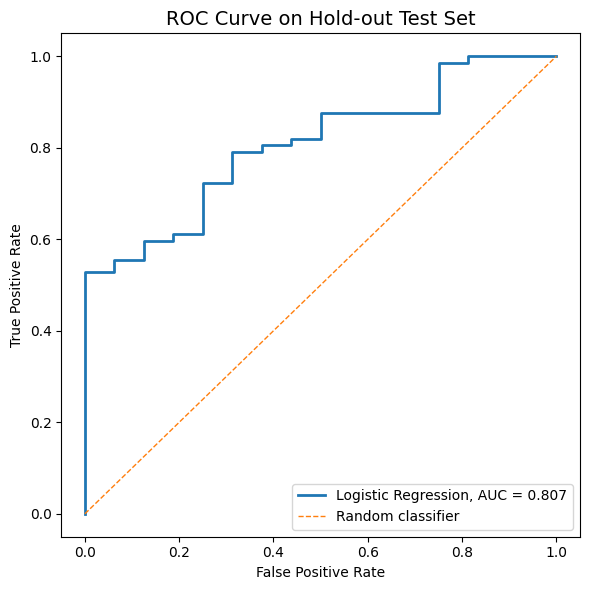

In [ ]:
# ============================================================
# 9. ROC CURVE FOR HOLD-OUT TEST SET
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression, AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.title("ROC Curve on Hold-out Test Set", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

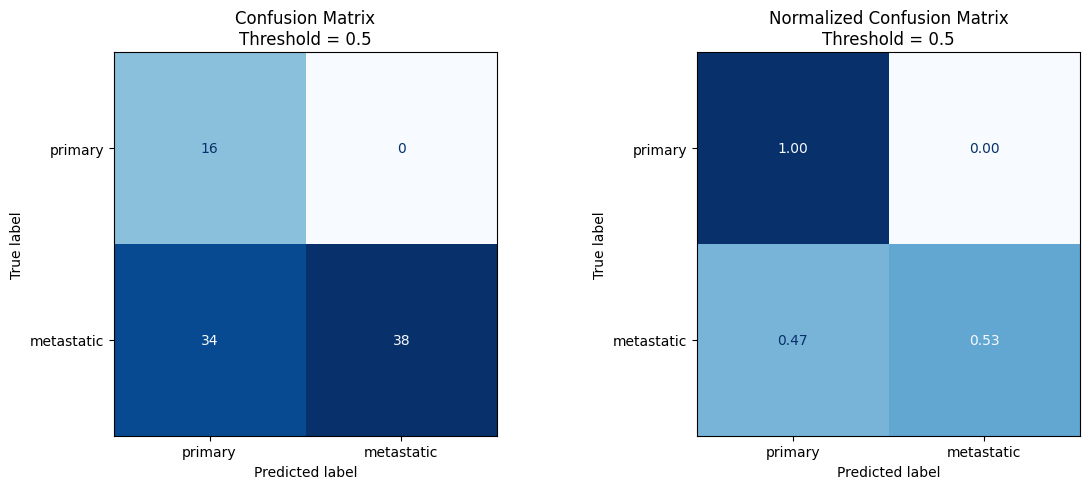

In [ ]:
# ============================================================
# 10. CONFUSION MATRICES: RAW + NORMALIZED SIDE BY SIDE
# ============================================================

cm = confusion_matrix(y_test, pred)
cm_norm = confusion_matrix(y_test, pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw confusion matrix
disp_raw = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["primary", "metastatic"]
)

disp_raw.plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[0].set_title("Confusion Matrix\nThreshold = 0.5")


# Normalized confusion matrix
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["primary", "metastatic"]
)

disp_norm.plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
    values_format=".2f"
)

axes[1].set_title("Normalized Confusion Matrix\nThreshold = 0.5")

plt.tight_layout()
plt.show()

,threshold,recall_primary,recall_metastatic,balanced_accuracy
9,0.50,1.0000,0.527778,0.763889
8,0.45,0.9375,0.555556,0.746528
10,0.55,1.0000,0.486111,0.743056
14,0.75,1.0000,0.486111,0.743056
13,0.70,1.0000,0.486111,0.743056
12,0.65,1.0000,0.486111,0.743056
11,0.60,1.0000,0.486111,0.743056
15,0.80,1.0000,0.472222,0.736111
17,0.90,1.0000,0.458333,0.729167
16,0.85,1.0000,0.458333,0.729167


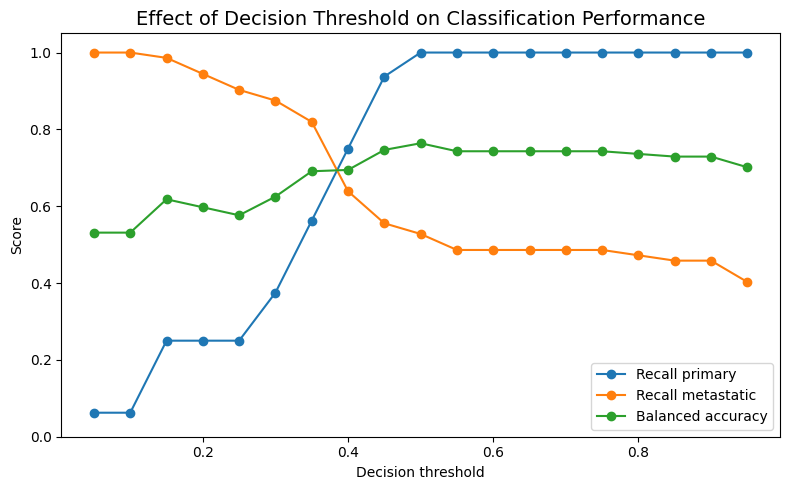

In [ ]:
# ============================================================
# 12. THRESHOLD ANALYSIS
# ============================================================

threshold_grid = np.linspace(0.05, 0.95, 19)

rows = []

for thr in threshold_grid:
    pred_thr = (proba >= thr).astype(int)

    recall_primary = recall_score(y_test, pred_thr, pos_label=0)
    recall_metastatic = recall_score(y_test, pred_thr, pos_label=1)
    bal_acc_thr = balanced_accuracy_score(y_test, pred_thr)

    rows.append({
        "threshold": thr,
        "recall_primary": recall_primary,
        "recall_metastatic": recall_metastatic,
        "balanced_accuracy": bal_acc_thr
    })

thr_df = pd.DataFrame(rows)

display(thr_df.sort_values("balanced_accuracy", ascending=False))

plt.figure(figsize=(8, 5))

plt.plot(
    thr_df["threshold"],
    thr_df["recall_primary"],
    marker="o",
    label="Recall primary"
)

plt.plot(
    thr_df["threshold"],
    thr_df["recall_metastatic"],
    marker="o",
    label="Recall metastatic"
)

plt.plot(
    thr_df["threshold"],
    thr_df["balanced_accuracy"],
    marker="o",
    label="Balanced accuracy"
)

plt.title("Effect of Decision Threshold on Classification Performance", fontsize=14)
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 13. USE BEST THRESHOLD ACCORDING TO BALANCED ACCURACY
# ============================================================

best_row = thr_df.sort_values("balanced_accuracy", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Best threshold according to balanced accuracy:", best_threshold)
print(best_row)

pred_best = (proba >= best_threshold).astype(int)

print("\nConfusion matrix with best threshold:")
print(confusion_matrix(y_test, pred_best))

print("\nClassification report with best threshold:")
print(classification_report(
    y_test,
    pred_best,
    target_names=["primary", "metastatic"]
))

Best threshold according to balanced accuracy: 0.49999999999999994
threshold            0.500000
recall_primary       1.000000
recall_metastatic    0.527778
balanced_accuracy    0.763889
Name: 9, dtype: float64

Confusion matrix with best threshold:
[[16  0]
 [34 38]]

Classification report with best threshold:
              precision    recall  f1-score   support

     primary       0.32      1.00      0.48        16
  metastatic       1.00      0.53      0.69        72

    accuracy                           0.61        88
   macro avg       0.66      0.76      0.59        88
weighted avg       0.88      0.61      0.65        88



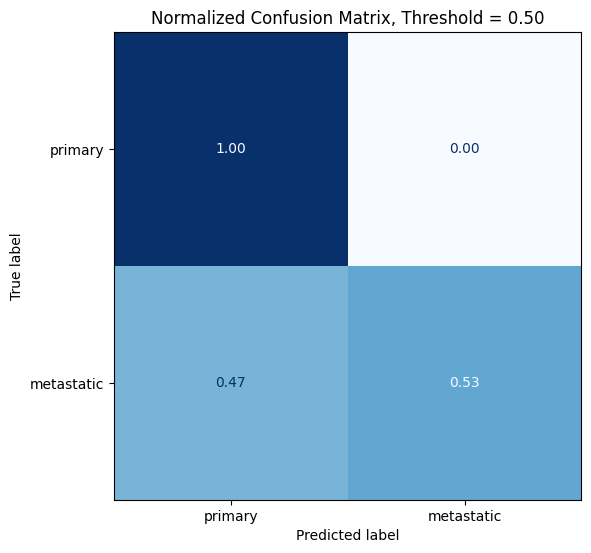

In [ ]:
# ============================================================
# 14. CONFUSION MATRIX WITH BEST THRESHOLD
# ============================================================

cm_best_norm = confusion_matrix(y_test, pred_best, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_norm,
    display_labels=["primary", "metastatic"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format=".2f"
)

plt.title(f"Normalized Confusion Matrix, Threshold = {best_threshold:.2f}")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 15. CROSS-VALIDATION FOR LOGISTIC REGRESSION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
    "f1": "f1"
}

cv_scores = cross_validate(
    logreg_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("=== Logistic Regression: 5-fold cross-validation ===")

for metric in scoring:
    values = cv_scores[f"test_{metric}"]
    print(f"{metric}: {values.mean():.3f} ± {values.std():.3f}")

=== Logistic Regression: 5-fold cross-validation ===
roc_auc: 0.762 ± 0.045
average_precision: 0.945 ± 0.013
balanced_accuracy: 0.717 ± 0.037
accuracy: 0.608 ± 0.037
f1: 0.696 ± 0.038


In [ ]:
# ============================================================
# 16. COMPARE MULTIPLE MODELS WITH CROSS-VALIDATION
# ============================================================

models = {
    "Logistic regression": Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            min_samples_leaf=5,
            random_state=42
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", HistGradientBoostingClassifier(
            max_iter=200,
            l2_regularization=0.1,
            random_state=42
        ))
    ])
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {"model": name}

    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[metric] = f"{values.mean():.3f} ± {values.std():.3f}"

    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

,model,roc_auc,average_precision,balanced_accuracy,accuracy,f1
0,Logistic regression,0.762 ± 0.045,0.945 ± 0.013,0.717 ± 0.037,0.608 ± 0.037,0.696 ± 0.038
1,Random forest,0.692 ± 0.030,0.910 ± 0.020,0.589 ± 0.035,0.736 ± 0.018,0.835 ± 0.014
2,HistGradientBoosting,0.607 ± 0.074,0.887 ± 0.023,0.514 ± 0.024,0.754 ± 0.027,0.855 ± 0.018


,model,roc_auc,balanced_accuracy,average_precision,accuracy
0,Logistic regression,0.761556,0.717061,0.944606,0.608177
1,Random forest,0.692251,0.588978,0.910295,0.735711
2,HistGradientBoosting,0.607088,0.514022,0.886598,0.753997


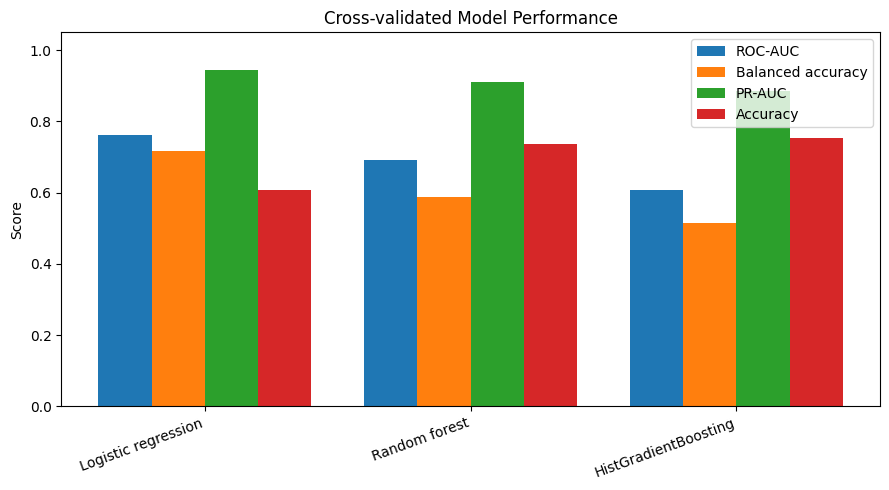

In [ ]:
# ============================================================
# 17. MODEL COMPARISON PLOT
# ============================================================

# For plotting, calculate numeric CV means separately

plot_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    plot_rows.append({
        "model": name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "average_precision": scores["test_average_precision"].mean(),
        "accuracy": scores["test_accuracy"].mean()
    })

plot_results_df = pd.DataFrame(plot_rows)

display(plot_results_df)

plt.figure(figsize=(9, 5))

x = np.arange(len(plot_results_df))
width = 0.2

plt.bar(
    x - 1.5 * width,
    plot_results_df["roc_auc"],
    width,
    label="ROC-AUC"
)

plt.bar(
    x - 0.5 * width,
    plot_results_df["balanced_accuracy"],
    width,
    label="Balanced accuracy"
)

plt.bar(
    x + 0.5 * width,
    plot_results_df["average_precision"],
    width,
    label="PR-AUC"
)

plt.bar(
    x + 1.5 * width,
    plot_results_df["accuracy"],
    width,
    label="Accuracy"
)

plt.xticks(x, plot_results_df["model"], rotation=20, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Cross-validated Model Performance")
plt.legend()

plt.tight_layout()
plt.show()

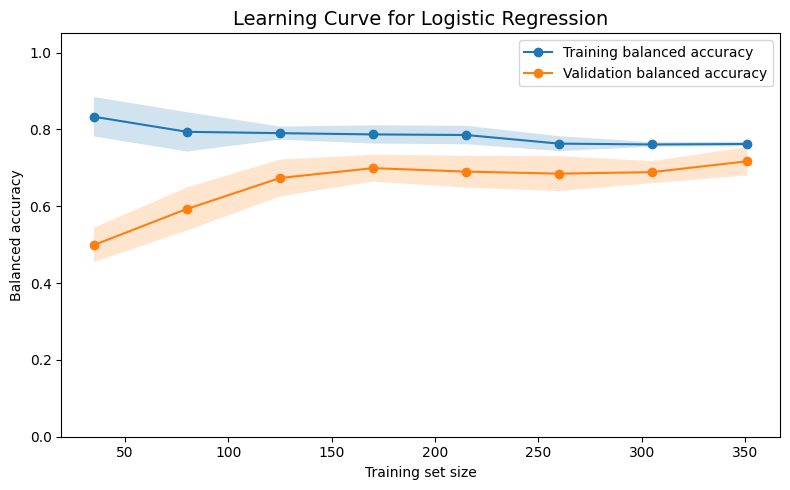

In [ ]:
# ============================================================
# 18. LEARNING CURVE FOR LOGISTIC REGRESSION
# ============================================================

train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X,
    y=y,
    cv=cv,
    scoring="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training balanced accuracy"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation balanced accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.title("Learning Curve for Logistic Regression", fontsize=14)
plt.xlabel("Training set size")
plt.ylabel("Balanced accuracy")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()